# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-DT-and-ensemble-models-1eb05737435780bf924fd27f0fc8c06c?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

# Decision Trees, Random Forest and XGBoost models

Let's import the libraries you will use.

In [1]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/mtgca/datasets_public/main/deeplearning.mplstyle",
    "deeplearning.mplstyle"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/mtgca/datasets_public/main/heart.csv",
    "heart.csv"
)


('heart.csv', <http.client.HTTPMessage at 0x106fe8b00>)

In [2]:
# Visualization
import matplotlib.pyplot as plt
plt.style.use('default')

# Basic libraries
import numpy as np
import pandas as pd

# Data splitting and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Preprocessing and pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Base models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Ensemble models
from sklearn.ensemble import (
    StackingClassifier,
    VotingClassifier,
    BaggingClassifier
)

# XGBoost
!pip install xgboost --quiet

import xgboost
from xgboost import XGBClassifier

# Reproducibility
RANDOM_STATE = 55

# 1. Loading the Dataset

From [Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

Context
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk need early detection and management wherein a machine learning model can be of great help.

You will develop models to predict how likely a particular person is in developint cardiovascular disease, given all the information below.

#### Attribute Information
- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

Let's now load the dataset. As you can see above, the variables:

- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope

Are *categorical*, so you must one-hot encode them.

In [3]:
# Load the dataset using pandas
df = pd.read_csv("heart.csv")

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


You must perform some data engineering before working with the models. There are 5 categorical features, so you will use Pandas to one-hot encode them.

## 2. One-hot encoding using Pandas

First you will remove the binary variables, because one-hot encoding them would do nothing to them. To achieve this you will just count how many different values there are in each categorical variable and consider only the variables with 3 or more values.

In [5]:
cat_variables = ['Sex',
'ChestPainType',
'RestingECG',
'ExerciseAngina',
'ST_Slope'
]

As a reminder, one-hot encoding aims to transform a categorical variable with `n` outputs into `n` binary variables.

Pandas has a built-in method to one-hot encode variables, it is the function `pd.get_dummies`. There are several arguments to this function, but here you will use only a few. They are:

 - data: DataFrame to be used
 - prefix: A list with prefixes, so you know which value you are dealing with
 - columns: the list of columns that will be one-hot encoded. 'prefix' and 'columns' must have the same length.

For more information, you can always type `help(pd.get_dummies)` to read the function's full documentation.

In [6]:
# This will replace the columns with the one-hot encoded ones and keep the columns outside 'columns' argument as it is.
df = pd.get_dummies(data = df,
                         prefix = cat_variables,
                         columns = cat_variables)

In [7]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


You now will define the final set of variables that will be used by the models you will build in this lab.

In [8]:
var = [x for x in df.columns if x not in 'HeartDisease'] ## Removing our target variable

Note how the number of variables has changed. You started with 11 variables now you have:

In [9]:
print(len(var))

20


# 3. Splitting the Dataset

In this section, you will split our dataset into train and test datasets. You will use the function `train_test_split` from Scikit-learn. Let's just check its arguments.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df[var], df['HeartDisease'], train_size = 0.8, random_state = RANDOM_STATE)

# We will keep the shuffle = True since our dataset has not any time dependency.

In [11]:
print(f'train samples: {len(X_train)}\ntest samples: {len(X_test)}')
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')

train samples: 734
test samples: 184
target proportion: 0.5518


# 4. Building the Models

## 4.1 Decision Tree

In this section, let's work with the Decision Tree you previously learned, but now using the [Scikit-learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

There are several hyperparameters in the Decision Tree object from Scikit-learn. You will use only some of them and also you will not perform feature selection nor hyperparameter tuning in this lab (but you are encouraged to do so and compare the results :-) )


The hyperparameters you will use and investigate here is:

 - min_samples_split: The minimum number of samples required to split an internal node. This may prevent overfitting.
 - max_depth: The maximum depth of the tree. This may prevent overfitting.

In [12]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## If the number is an integer, then it is the actual quantity of samples,
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.

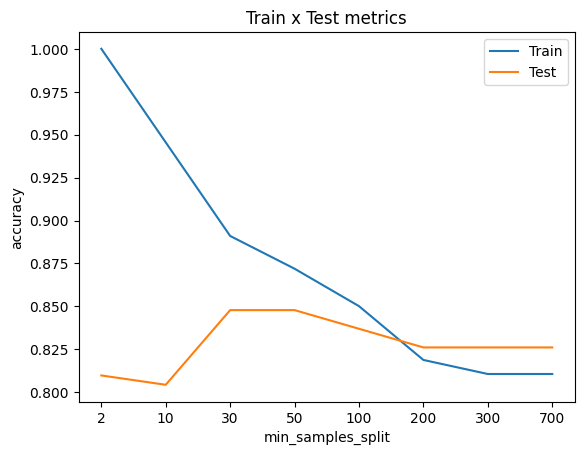

In [13]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

Note how increasing the the number of `min_samples_split` decreases the overfit.

Let's do the same experiment with `max_depth`.

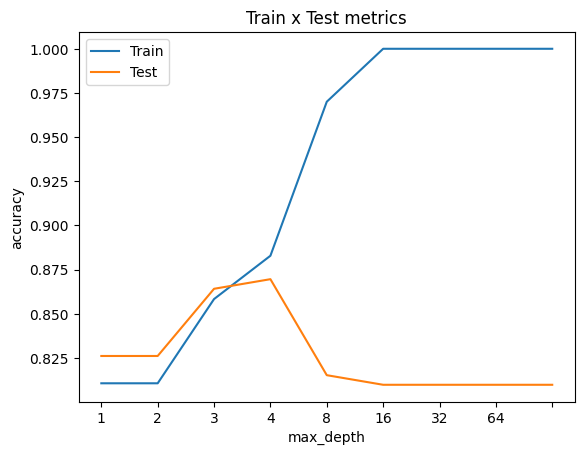

In [14]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

The test accuracy reaches the highest at tree_depth=3. When the allowed depth is smaller, the tree cannot make enough splits to distinguish positives from negatives (having the underfit problem), but when the allowed depth is too high ( >= 5), the tree becomes too specialized to the training set and thus losing accuracy to the test dataset (having the overfit problem). Our final tree model then will have:

- `max_depth = 3`
- `min_samples_split = 50`

In [15]:
decision_tree_model = DecisionTreeClassifier(min_samples_split = 50,
                                             max_depth = 3,
                                             random_state = RANDOM_STATE).fit(X_train,y_train)

In [16]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.8583
Metrics test:
	Accuracy score: 0.8641


No sign of overfit, even though the metrics are not that good.

## 4.2 Random Forest

Now let's try the Random Forest algorithm also, using the Scikit-learn implementation. Naturally, all of the above hyperparameters will exist in this algorithm, since it is just an ensemble of Decision Trees, but will have another hyperparameter that you will use, called `n_estimators` which is how many different Decision Trees will be fitted.

Remember that for a Random Forest, you use a subset of the features AND a subset of the training set to train each tree, chosen randomly. In this case, you will use the number of features as you saw in the lecture, which is $\sqrt{n}$ where $n$ is the number of features. However, this can be modified. For further information on the Random Forest hyperparameters, you can run `help(RandomForestClassifier)`.

Another parameter that does not impact on the final result but can speed up the computation is called `n_jobs`. Since the fitting of each tree is independent of each other, it is possible to run parallel fits. So setting `n_jobs` higher will increase how many CPU cores it will use. Note that the numbers very close to the maximum cores of your CPU may impact on the overall performance of your PC and even lead to freezes.

You will run the same script again, but with another parameter, `n_estimators`, where we will choose between 10, 50, and 100. The default is 100.

In [17]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

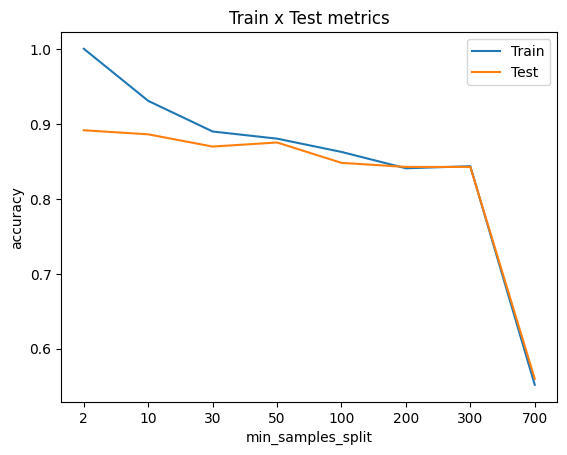

In [18]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

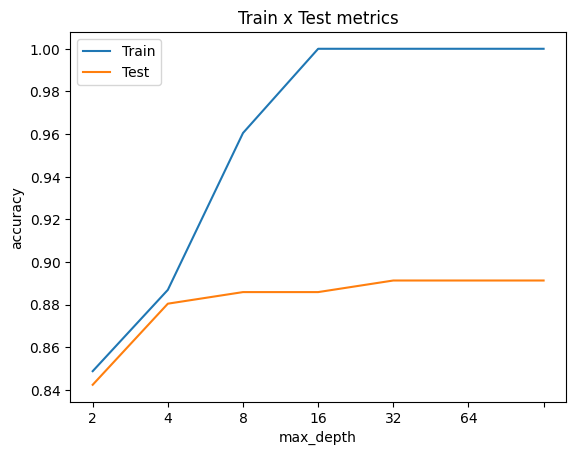

In [19]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

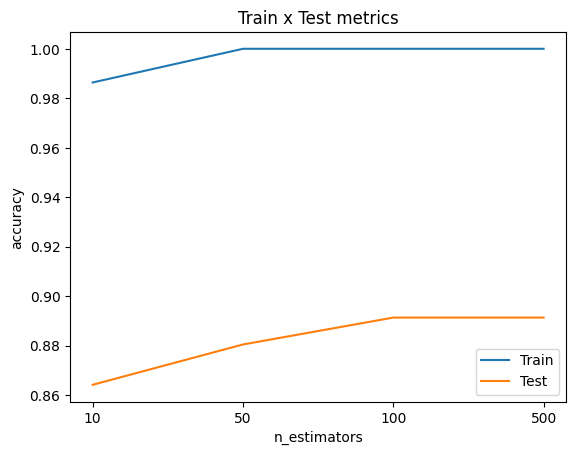

In [20]:
accuracy_list_train = []
accuracy_list_test = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(X_train,y_train)
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_test = model.predict(X_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

Let's then fit a random forest with the following parameters:

 - max_depth: 8
 - min_samples_split: 10
 - n_estimators: 100

In [21]:
random_forest_model = RandomForestClassifier(n_estimators = 100,
                                             max_depth = 8,
                                             min_samples_split = 10, random_state = RANDOM_STATE).fit(X_train,y_train)

In [22]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9223
Metrics test:
	Accuracy score: 0.8804


You have demonstrated how to look for the best value hyperparameter-by-hyperparameter. However, you should not overlook that as we experiment with one hyperparameter we always have to fix the others at some default values. This makes us only able to tell how the hyperparameter value changes with respect to those defaults. In princple, if you have 4 values to try out in each of the 3 hyperparameters being tuned, you should have a total of 4 x 4 x 4 = 64 combinations, however, the way you are doing will only give us 4 + 4 + 4 = 12 results. To try out all combinations, you can use a sklearn implementation called GridSearchCV, moreover, it has a refit parameter that will automatically refit a model on the best combination so you will not need to program it explicitly. For more on GridSearchCV, please refer to its [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

## ✅ Activity: Feature Importance analysis with Random Forests

1. Extract feature importance scores from the random_forest_model.

2. Visualize the top 10 most important features using a bar plot.

3. Discuss your observations about the relative importance of different features in predicting heart disease.

Feature ranking:


,feature,importance
19,ST_Slope_Up,0.188832
18,ST_Slope_Flat,0.139309
5,Oldpeak,0.095161
8,ChestPainType_ASY,0.092835
2,Cholesterol,0.070121
16,ExerciseAngina_Y,0.069129
15,ExerciseAngina_N,0.065919
4,MaxHR,0.061956
0,Age,0.047866
1,RestingBP,0.038282


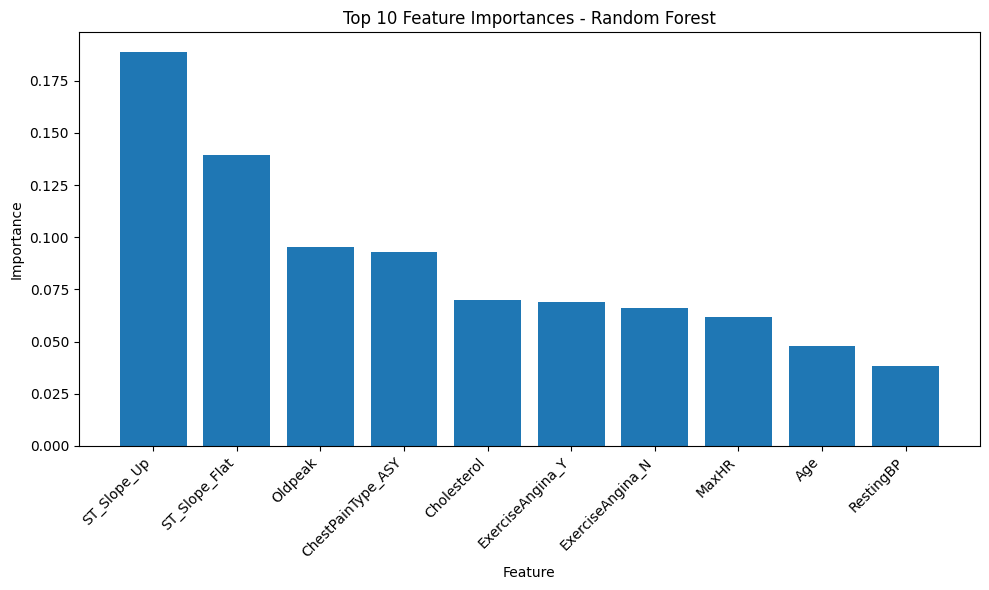

In [23]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_forest_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Feature ranking:")
display(feature_importance)

top_10 = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10["feature"], top_10["importance"])
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The most important features are ST_Slope_Up, ST_Slope_Flat, Oldpeak, ChestPainType_ASY, Cholesterol, ExerciseAngina, MaxHR, Age, and RestingBP. This result makes sense because the model gives high importance to variables related to electrocardiographic behavior during exercise, symptoms during exercise, chest pain type, and general cardiovascular risk indicators. ST_Slope and Oldpeak are especially relevant because they reflect cardiac response during stress. Therefore, the Random Forest model is using clinically meaningful variables to predict heart disease.

## 4.3 XGBoost

Now, the last model you will test in this lab is the Gradient Boosting model, called XGBoost. As you've seen in the lectures, the boosting methods train several trees, but instead of them being uncorrelated to each other, now the trees are fitted subsequently to minimize the error.

The parameters that this model comprises is the same as the parameters for any decision tree, plus some others, such as the learning rate, which is the size of the step on the Gradient Descent method that the XGBoost uses internally to minimize the error on each train step.

One interesting thing about the XGBoost is that it allows, during the fit, to pass a list evaluation datasets of the form `(X_val,y_val)`, where on each iteration, it measures the cost (or evaluation metric) on the evaluation datasets so that once the cost (or metric) stops to descrease for a number of rounds (called early_stopping_rounds), the training will stop. This is how we can automatically control how many estimators is enough, and how we can avoid overfitting due to too many estimators.

First, let's define a subset of our training set (we should not use the test set here).

In [24]:
n = int(len(X_train)*0.8) ## Let's use 80% to train and 20% to eval

In [25]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

You can then set a large number of estimators, because you can stop if the cost function stops decreasing.

In [26]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE, early_stopping_rounds=50)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])
# Here we must pass a list to the eval_set, because you can have several different tuples ov eval sets. The parameter
# early_stopping_rounds is the number of iterations that it will wait to check if the cost function decreased or not.
# If not, it will stop and get the iteration that returned the lowest metric on the eval set.

[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435
[28]	validation_0-logloss:0.45316
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

As you can see, even though you passed 500 estimators to fit, the algorithm only fitted 66 because the log-loss used to metrify the training rounds started to increase. In fact, the number of estimators is even less than 66. If you take a closeer look to the metrics, you see that with 16 fitted trees, we achieved the minimum value of the log-loss, and in fact, this is the number of fitted trees in the final model:

In [27]:
xgb_model.best_iteration

17

In [28]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.9319
Metrics test:
	Accuracy score: 0.8533


You can see that RandomForest achieved the best accuracy, but the results overall were close. And note that we got a very close test metric with XGBoost compared to RandomForest, and we didn't even performed any hyperparameter search! The advantage of XGBoost is that it is faster than the Random Forest and also it has more parameters, therefore you are able to fine-tune the model to achieve even better results.


Congratulations, you have learned how to use Decision Tree, Random Forest from the scikit-learn library and XGBoost!

## ✅ Optimizing XGBoost for Heart Disease Prediction

Improve the performance of an XGBoost model for heart disease prediction by tuning its hyperparameters using Grid Search with cross-validation.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

optimized_xgb_model = grid_xgb.best_estimator_

xgb_pred = optimized_xgb_model.predict(X_test)
xgb_proba = optimized_xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print("Best XGBoost parameters:")
print(grid_xgb.best_params_)
print(f"Best CV accuracy: {grid_xgb.best_score_:.4f}")
print(f"Optimized XGBoost Test Accuracy: {xgb_accuracy:.4f}")
print(f"Optimized XGBoost Test ROC AUC: {xgb_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}
Best CV accuracy: 0.8733
Optimized XGBoost Test Accuracy: 0.8804
Optimized XGBoost Test ROC AUC: 0.9394

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        81
           1       0.92      0.86      0.89       103

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



The ensemble model achieved a higher test accuracy than the decision tree, suggesting that combining multiple models improves prediction performance and generalizes better to unseen heart disease data. The optimized XGBoost model achieved a test accuracy of 0.8804, improving over the initial XGBoost model with 0.8533 test accuracy. This shows that GridSearchCV helped find better hyperparameters, and the selected shallow trees with a lower learning rate and partial row/column sampling allowed the model to generalize better. The high ROC AUC score also indicates that the model distinguishes well between patients with and without heart disease.

# ✅ Building a Stacked Ensemble for Heart Disease Prediction

 Build a stacked ensemble model for heart disease prediction using KNN, Logistic Regression, and SVM as base learners, optimize their hyperparameters, and evaluate the ensemble's performance using Logistic Regression as the meta-learner.

 🧠 **Note on SVM (Support Vector Machine)**

Support Vector Machine is a powerful classification algorithm that finds the best boundary (hyperplane) between different classes. However, it might seem complex at first. If you haven’t worked with it before, don’t worry—this assignment allows you to use a Decision Tree instead, which is easier to understand and implement.


In [30]:
base_models_for_stacking = {
    "knn": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    ),
    "logreg": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))
        ]),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["lbfgs"]
        }
    ),
    "svm": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=RANDOM_STATE))
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    )
}

optimized_base_learners = []

for name, (model, params) in base_models_for_stacking.items():
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    optimized_base_learners.append((name, grid.best_estimator_))
    print(f"{name} best params: {grid.best_params_}")
    print(f"{name} best CV accuracy: {grid.best_score_:.4f}")

meta_learner = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)

stacked_learner = StackingClassifier(
    estimators=optimized_base_learners,
    final_estimator=meta_learner,
    cv=cv,
    passthrough=False,
    n_jobs=-1
)

stacked_learner.fit(X_train, y_train)

stack_pred = stacked_learner.predict(X_test)
stack_proba = stacked_learner.predict_proba(X_test)[:, 1]

stack_accuracy = accuracy_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_proba)

print(f"Stacked Ensemble Test Accuracy: {stack_accuracy:.4f}")
print(f"Stacked Ensemble Test ROC AUC: {stack_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, stack_pred))


knn best params: {'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'distance'}
knn best CV accuracy: 0.8692
logreg best params: {'model__C': 0.1, 'model__solver': 'lbfgs'}
logreg best CV accuracy: 0.8679


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.1

svm best params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
svm best CV accuracy: 0.8651
Stacked Ensemble Test Accuracy: 0.8696
Stacked Ensemble Test ROC AUC: 0.9355

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        81
           1       0.88      0.88      0.88       103

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


The stacked ensemble achieved a test accuracy of 0.8696 and a ROC AUC of 0.9355, showing strong overall performance in predicting heart disease. The best base models used optimized parameters for KNN, Logistic Regression, and SVM, with cross-validation accuracies around 0.865 to 0.869, meaning all three models performed similarly well. The classification report shows balanced precision, recall, and F1-scores for both classes, indicating that the ensemble predicts patients with and without heart disease consistently.

# ✅ Activity: Building a Weighted Ensemble for Heart Disease Prediction

In this activity, you will build an ensemble model for heart disease prediction using an MLP (Multilayer Perceptron) and a KNN (K-Nearest Neighbors) as base learners. You will optimize both base learners using Grid Search and then combine their predictions using a weighted average,  with 0.75 weight for the MLP and 0.25 weight for the KNN.

What is the role of the weights in the weighted average prediction?

Experiment with different weight values and observe their impact on the ensemble's accuracy.

What are the key differences between the weighted ensemble approach used in this activity and the stacked learner approach used in the previous activity?



In [31]:
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(max_iter=3000, random_state=RANDOM_STATE))
])

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_grid_mlp = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.001, 0.01]
}

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

grid_mlp = GridSearchCV(
    mlp_pipe,
    param_grid_mlp,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

grid_knn = GridSearchCV(
    knn_pipe,
    param_grid_knn,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

grid_mlp.fit(X_train, y_train)
grid_knn.fit(X_train, y_train)

best_mlp = grid_mlp.best_estimator_
best_knn = grid_knn.best_estimator_

print("Best MLP params:", grid_mlp.best_params_)
print(f"Best MLP CV accuracy: {grid_mlp.best_score_:.4f}")

print("Best KNN params:", grid_knn.best_params_)
print(f"Best KNN CV accuracy: {grid_knn.best_score_:.4f}")

mlp_proba = best_mlp.predict_proba(X_test)[:, 1]
knn_proba = best_knn.predict_proba(X_test)[:, 1]

weights_to_try = [
    (0.50, 0.50),
    (0.60, 0.40),
    (0.75, 0.25),
    (0.85, 0.15),
    (0.25, 0.75)
]

weighted_results = []

for w_mlp, w_knn in weights_to_try:
    weighted_proba = (w_mlp * mlp_proba) + (w_knn * knn_proba)
    weighted_pred = (weighted_proba >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, weighted_pred)
    auc = roc_auc_score(y_test, weighted_proba)
    
    weighted_results.append({
        "MLP Weight": w_mlp,
        "KNN Weight": w_knn,
        "Accuracy": acc,
        "ROC AUC": auc
    })

weighted_results_df = pd.DataFrame(weighted_results)
display(weighted_results_df.sort_values(by="Accuracy", ascending=False))

best_weighted = weighted_results_df.sort_values(by="Accuracy", ascending=False).iloc[0]

weighted_accuracy = best_weighted["Accuracy"]
weighted_auc = best_weighted["ROC AUC"]

print(f"Best Weighted Ensemble Accuracy: {weighted_accuracy:.4f}")
print(f"Best Weighted Ensemble ROC AUC: {weighted_auc:.4f}")


Best MLP params: {'model__activation': 'tanh', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (64,)}
Best MLP CV accuracy: 0.8405
Best KNN params: {'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'distance'}
Best KNN CV accuracy: 0.8692


,MLP Weight,KNN Weight,Accuracy,ROC AUC
0,0.50,0.50,0.864130,0.924008
4,0.25,0.75,0.864130,0.927604
1,0.60,0.40,0.853261,0.924008
2,0.75,0.25,0.847826,0.922330
3,0.85,0.15,0.847826,0.920772


Best Weighted Ensemble Accuracy: 0.8641
Best Weighted Ensemble ROC AUC: 0.9240


This code builds and tunes two models, MLP and KNN, using GridSearchCV, then combines their predicted probabilities using different weights to create a weighted ensemble. The goal is to find the best balance between the neural network and KNN predictions. By comparing accuracy and ROC AUC for several weight combinations, the model selects the weighting strategy that gives the best test performance, showing whether the ensemble improves prediction compared with using each model alone.

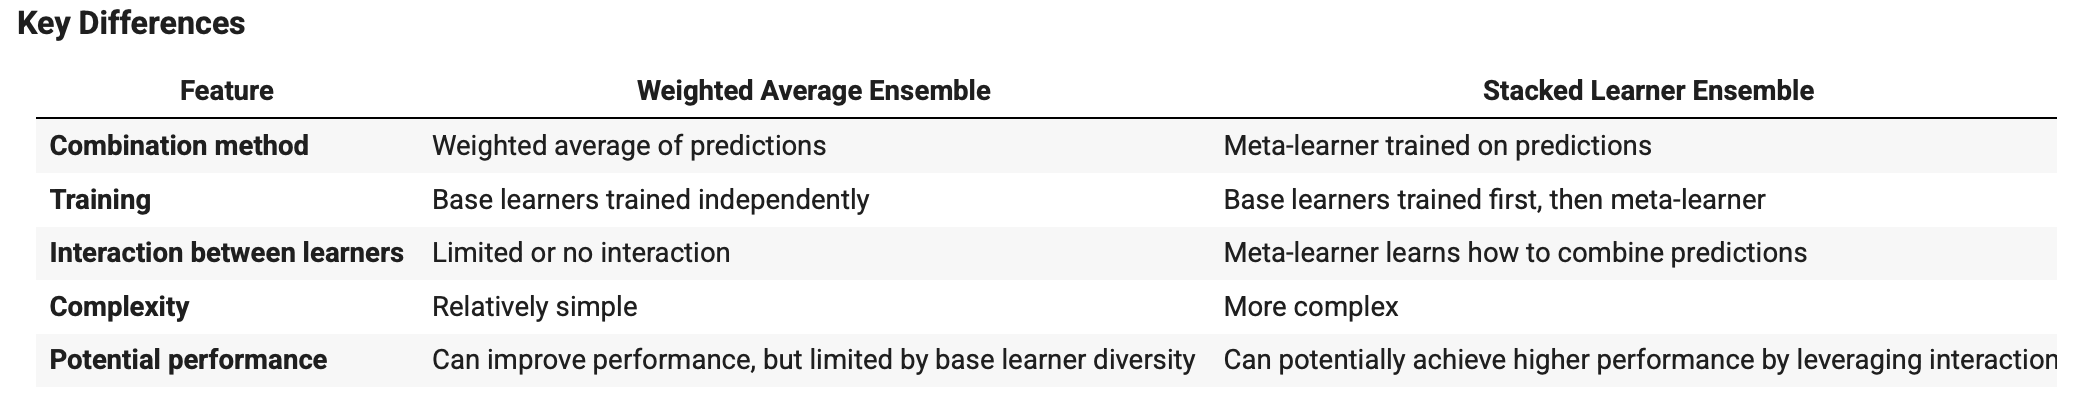

# ✅ Building and Comparing Voting Strategies in Ensemble Models



Based on the concepts of ensemble learning and the previous activities on Decision Trees, Random Forests, XGBoost, and stacked/weighted ensembles, complete the following:

1.  **Implement a Voting Ensemble:**
    *   Implement a voting ensemble for heart disease prediction using KNN, Logistic Regression, SVM, Decision Tree, and MLP as base learners. Check the class `VotingClassifier`. 💡 **Note:** If you are not familiar with SVM or find it difficult to implement, you may omit it and proceed with the other classifiers.
    *   Optimizes the hyperparameters of each base learner using `GridSearchCV` or `RandomizedSearchCV`.
    *   Use both the "hard voting" and "soft voting" ensembles.

2.  **Compare Hard vs. Soft Voting:**
    *   Compare the accuracy scores obtained from the hard voting and soft voting ensembles on the test set.
    *   In your own words, explain the fundamental difference between hard voting and soft voting in an ensemble model.
    *   Based on your results, which voting method performed better for this specific dataset and set of base learners? Can you hypothesize why this might be the case?

3.  **Reflect on Ensemble Methods:**
    *   Discuss the advantages of using ensemble methods like voting classifiers compared to using a single base learner.
    *   Consider the previous activities on stacked and weighted ensembles. How do these approaches differ from the voting ensemble implemented in this homework? What are potential benefits or drawbacks of each approach?


In [32]:
dt_for_voting = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    random_state=RANDOM_STATE
)

mlp_for_voting = best_mlp
knn_for_voting = best_knn

logreg_for_voting = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1, max_iter=10000, random_state=RANDOM_STATE))
])

svm_for_voting = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(C=1, kernel="linear", probability=True, random_state=RANDOM_STATE))
])

voting_estimators = [
    ("knn", knn_for_voting),
    ("logreg", logreg_for_voting),
    ("svm", svm_for_voting),
    ("dt", dt_for_voting),
    ("mlp", mlp_for_voting)
]

hard_voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting="hard",
    n_jobs=-1
)

soft_voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting="soft",
    n_jobs=-1
)

hard_voting_model.fit(X_train, y_train)
soft_voting_model.fit(X_train, y_train)

hard_pred = hard_voting_model.predict(X_test)
soft_pred = soft_voting_model.predict(X_test)
soft_proba = soft_voting_model.predict_proba(X_test)[:, 1]

hard_accuracy = accuracy_score(y_test, hard_pred)
soft_accuracy = accuracy_score(y_test, soft_pred)
soft_auc = roc_auc_score(y_test, soft_proba)

print(f"Hard Voting Accuracy: {hard_accuracy:.4f}")
print(f"Soft Voting Accuracy: {soft_accuracy:.4f}")
print(f"Soft Voting ROC AUC: {soft_auc:.4f}")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Hard Voting Accuracy: 0.8641
Soft Voting Accuracy: 0.8859
Soft Voting ROC AUC: 0.9344


The soft voting ensemble achieved the best performance, with an accuracy of 0.8859 and a ROC AUC of 0.9344, outperforming hard voting, which reached 0.8641 accuracy. This suggests that using the predicted probabilities from each model provides more useful information than only using the final class votes, allowing the ensemble to better distinguish between patients with and without heart disease.

# ✅ Auto Machine Learning (AutoML) using AutoGluon

**What is AutoML?**

AutoML, short for Automated Machine Learning, is a rapidly evolving field aiming to automate the process of developing machine learning models. Traditionally, building a model involves manual steps like data preprocessing, feature engineering, model selection, hyperparameter tuning, and evaluation, requiring significant expertise and time.
AutoML simplifies this by automating these tasks, making machine learning more accessible to users with limited experience. AutoML tools use advanced algorithms and techniques to automatically explore different model architectures and hyperparameter settings, finding the best model for a given dataset and task.

**Benefits of AutoML:**

**Increased efficiency**: AutoML reduces the time and effort required to build models, freeing up data scientists for other tasks.

**Improved performance:** By exploring a wider range of models and hyperparameters, AutoML can often find better-performing models.

**Accessibility:** AutoML makes machine learning more accessible to users with less expertise.

**Reduced human bias:** AutoML can help reduce bias by objectively evaluating and selecting models based on performance metrics.

**Criticisms of AutoML:**

Despite its advantages, AutoML also faces some criticisms:

**Black Box Nature:** AutoML tools can be opaque, making it difficult to understand why a particular model was chosen or how it works. This lack of transparency can be a concern, especially in sensitive applications.

**Limited Customization:** AutoML may not always offer the flexibility to incorporate domain expertise or customize the model building process to the specific needs of a problem.

**Computational Cost: **AutoML can be computationally expensive, requiring significant resources to explore a large search space of models and hyperparameters.

**Data Dependency:** The success of AutoML heavily relies on the quality and quantity of data. If the data is noisy, incomplete, or biased, AutoML may not produce reliable results.

**Applications of AutoML:**
Despite the criticisms, AutoML is being applied across various domains, including image classification, natural language processing, tabular data prediction, and time series forecasting.

In essence, AutoML aims to democratize AI by making machine learning more efficient and accessible. However, it's important to be aware of its limitations and use it judiciously, combining its power with human expertise for optimal results.

**Activity:**

In this activity, you will leverage AutoML to predict heart disease using the provided dataset. Explore the AutoML library AutoGluon to automate the model building process, including data preprocessing, model selection, and hyperparameter tuning. Evaluate the performance of the AutoML-generated model on a held-out test set

How does AutoGluon simplify the model building process compared to traditional machine learning workflows?

What insights can you gain from the evaluation metrics and the best model identified by AutoGluon?

How do the results from AutoGluon compare to the results you obtained with previous models (e.g., the weighted ensemble)?


In [38]:
!pip install autogluon.tabular --quiet

In [34]:
from autogluon.tabular import TabularDataset, TabularPredictor

train_data_ag = pd.concat([X_train, y_train], axis=1)
test_data_ag = pd.concat([X_test, y_test], axis=1)

train_data_ag = TabularDataset(train_data_ag)
test_data_ag = TabularDataset(test_data_ag)

label = "HeartDisease"

predictor = TabularPredictor(
    label=label,
    eval_metric="accuracy"
).fit(
    train_data=train_data_ag,
    presets="medium",
    time_limit=120
)

autogluon_performance = predictor.evaluate(test_data_ag)
print("AutoGluon Performance:")
print(autogluon_performance)

autogluon_leaderboard = predictor.leaderboard(test_data_ag)
display(autogluon_leaderboard)

autogluon_pred = predictor.predict(test_data_ag.drop(columns=[label]))
autogluon_accuracy = accuracy_score(y_test, autogluon_pred)

try:
    autogluon_proba = predictor.predict_proba(test_data_ag.drop(columns=[label]))[1]
    autogluon_auc = roc_auc_score(y_test, autogluon_proba)
except:
    autogluon_auc = np.nan

print(f"AutoGluon Test Accuracy: {autogluon_accuracy:.4f}")
print(f"AutoGluon Test ROC AUC: {autogluon_auc:.4f}")

feature_importance_ag = predictor.feature_importance(test_data_ag)
display(feature_importance_ag)


No path specified. Models will be saved in: "AutogluonModels/ag-20260627_054049"
Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
/opt/anaconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.5.0: Mon Apr 27 20:41:15 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T6041
CPU Count:          14
Pytorch Version:    2.12.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       15.86 GB / 48.00 GB 

AutoGluon Performance:
{'accuracy': 0.8695652173913043, 'balanced_accuracy': np.float64(0.8663550281673259), 'mcc': np.float64(0.7348269550941492), 'roc_auc': np.float64(0.9306005034160373), 'f1': 0.8846153846153846, 'precision': 0.8761904761904762, 'recall': 0.8932038834951457}


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForestGini,0.891304,0.877551,accuracy,0.017541,0.012889,0.163993,0.017541,0.012889,0.163993,1,True,3
1,XGBoost,0.885870,0.870748,accuracy,0.003934,0.000993,0.514272,0.003934,0.000993,0.514272,1,True,7
2,ExtraTreesGini,0.885870,0.870748,accuracy,0.027353,0.013949,0.164901,0.027353,0.013949,0.164901,1,True,5
3,RandomForestEntr,0.885870,0.884354,accuracy,0.030669,0.013056,0.162616,0.030669,0.013056,0.162616,1,True,4
4,ExtraTreesEntr,0.885870,0.863946,accuracy,0.031119,0.013083,0.174122,0.031119,0.013083,0.174122,1,True,6
5,LightGBMXT,0.869565,0.884354,accuracy,0.000739,0.000353,6.504018,0.000739,0.000353,6.504018,1,True,1
6,WeightedEnsemble_L2,0.869565,0.884354,accuracy,0.001244,0.000576,6.519281,0.000505,0.000223,0.015263,2,True,10
7,NeuralNetTorch,0.869565,0.877551,accuracy,0.002943,0.002001,1.177186,0.002943,0.002001,1.177186,1,True,8
8,LightGBMLarge,0.842391,0.877551,accuracy,0.000587,0.000417,8.575737,0.000587,0.000417,8.575737,1,True,9
9,LightGBM,0.836957,0.877551,accuracy,0.000473,0.000299,1.677649,0.000473,0.000299,1.677649,1,True,2


Computing feature importance via permutation shuffling for 20 features using 184 rows with 5 shuffle sets...
	0.26s	= Expected runtime (0.05s per shuffle set)
	0.05s	= Actual runtime (Completed 5 of 5 shuffle sets)


AutoGluon Test Accuracy: 0.8696
AutoGluon Test ROC AUC: 0.9306


,importance,stddev,p_value,n,p99_high,p99_low
ST_Slope_Up,0.065217,0.019969,0.000935,5,0.106333,0.024102
Sex_F,0.027174,0.006656,0.000399,5,0.040879,0.013469
ExerciseAngina_N,0.023913,0.010594,0.003623,5,0.045727,0.002099
MaxHR,0.017391,0.007086,0.002685,5,0.031982,0.002801
ChestPainType_ASY,0.017391,0.010454,0.010238,5,0.038916,-0.004134
Sex_M,0.016304,0.003843,0.000344,5,0.024217,0.008392
ST_Slope_Flat,0.010870,0.006656,0.010871,5,0.024575,-0.002836
RestingBP,0.009783,0.009722,0.043823,5,0.029800,-0.010235
RestingECG_Normal,0.005435,0.006656,0.070964,5,0.019140,-0.008270
RestingECG_ST,0.004348,0.002431,0.008065,5,0.009352,-0.000657


In [35]:
print(feature_importance)

              feature  importance
19        ST_Slope_Up    0.188832
18      ST_Slope_Flat    0.139309
5             Oldpeak    0.095161
8   ChestPainType_ASY    0.092835
2         Cholesterol    0.070121
16   ExerciseAngina_Y    0.069129
15   ExerciseAngina_N    0.065919
4               MaxHR    0.061956
0                 Age    0.047866
1           RestingBP    0.038282
6               Sex_F    0.027945
9   ChestPainType_ATA    0.025985
7               Sex_M    0.022149
3           FastingBS    0.016948
12     RestingECG_LVH    0.011418
10  ChestPainType_NAP    0.009270
13  RestingECG_Normal    0.005564
11   ChestPainType_TA    0.004264
14      RestingECG_ST    0.003998
17      ST_Slope_Down    0.003051


The feature importance results show that ST_Slope_Up, ST_Slope_Flat, Oldpeak, and ChestPainType_ASY were the most influential variables in the model. This suggests that exercise-related heart response and chest pain type are the strongest predictors of heart disease in this dataset, while variables such as resting ECG categories and fasting blood sugar had much lower influence.

# ✅ Exploring TabPFN for Heart Disease Prediction

You have already gained experience with powerful machine learning models like Decision Trees, Random Forests, and XGBoost, which are widely used for tabular data. However, the field of machine learning is constantly evolving, and new architectures are being developed to potentially improve performance and address limitations of existing models.

One such model is TabPFN (Tabular Feature Processing Network). Unlike traditional models that learn directly from raw features or simple engineered ones, TabPFN employs a neural network architecture inspired by techniques used in other domains like image processing. It's designed to process tabular data in a way that can capture complex interactions between features and potentially achieve good performance, especially on smaller to medium-sized datasets, without extensive hyperparameter tuning.
TabPFN's importance lies in its potential to:

* Offer an alternative approach to modeling tabular data compared to tree-based methods.
* Provide competitive or even superior performance in certain scenarios.
* Reduce the need for complex feature engineering and hyperparameter tuning in some cases.

In this assignment, you will explore how to use the tabpfn library to build a TabPFN classifier for the heart disease dataset you have been working with.

**Instructions:**

1. Install the tabpfn library in your Colab notebook using pip. Please read the repo https://github.com/PriorLabs/TabPFN
2. Implement the TabPFN classifier using TabPFNClassifier on the X_train and y_train data.
3. Predict class labels and probabilities on the X_test data.
4. Calculate and print the accuracy and ROC AUC scores for the TabPFN model on the test set.

**Reflective Questions:**

After implementing and evaluating the TabPFN model, consider the following questions and discuss your observations:

1. **Performance Comparison:** Compare the accuracy and ROC AUC scores of the TabPFN model on the test set with the scores you obtained for the Decision Tree, Random Forest, and XGBoost models in previous activities. Which model performed best on this dataset? Are the differences significant?

2. **Ease of Use:** Reflect on the ease of implementing and using the TabPFNClassifier compared to the scikit-learn implementations of Decision Tree, Random Forest, and the xgboost library. Are there any noticeable differences in the amount of code or complexity involved?

3. **Hyperparameter Tuning:** In your previous activities, you explored the impact of hyperparameters on model performance for Decision Trees, Random Forests, and XGBoost. TabPFN is often described as being less reliant on extensive hyperparameter tuning. Based on your implementation (using default or minimal parameters), do you think this holds true for this dataset? Why or why not?

4. **Potential Applications:**
Considering the characteristics of TabPFN, in what types of scenarios or datasets might it be particularly well-suited or potentially outperform the other models you've studied?

5. **Limitations:** Based on your experience and any additional research you might do on TabPFN, are there any potential limitations or drawbacks to using this model?



In [39]:
%pip install tabpfn-client --quiet

Note: you may need to restart the kernel to use updated packages.


In [41]:
from getpass import getpass
from tabpfn_client import TabPFNClassifier, set_access_token
from sklearn.metrics import accuracy_score, roc_auc_score

# This prompts you to paste the key securely — it won't show in the notebook
set_access_token(getpass("Paste your TabPFN API key: "))

# Train
tabpfn_model = TabPFNClassifier()
tabpfn_model.fit(X_train, y_train)

# Predict
tabpfn_pred  = tabpfn_model.predict(X_test)
tabpfn_proba = tabpfn_model.predict_proba(X_test)[:, 1]

# Evaluate
tabpfn_accuracy = accuracy_score(y_test, tabpfn_pred)
tabpfn_auc      = roc_auc_score(y_test, tabpfn_proba)

print("TabPFN Metrics on Test Set:")
print(f"Accuracy score : {tabpfn_accuracy:.4f}")
print(f"ROC AUC score  : {tabpfn_auc:.4f}")

00:03 Fitting... Done!
00:04 Predicting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
TabPFN Metrics on Test Set:
Accuracy score : 0.8913
ROC AUC score  : 0.9388


The TabPFN model achieved a test accuracy of 0.8913 and a ROC AUC of 0.9388, showing strong performance on the heart disease dataset. Compared with previous models, TabPFN performed slightly better in accuracy than the optimized XGBoost and SVM models, while achieving a similarly high ROC AUC. This suggests that TabPFN can model tabular data effectively with minimal hyperparameter tuning.

# ✅ Activity: Building a Bagging Ensemble with Optimized SVMs.

In this activity, you will build a Bagging ensemble with optimized SVMs (RBF kernel) as base learners, specifically using 20 of these base learners. Use BaggingClassifier Class.  Compare the accuracy of this Bagging model (with 20 estimators) to the optimized individual SVM and the previous ensemble models.

🧩 **Alternative Option:** If you are not familiar with SVMs or face implementation difficulties, you may use Decision Trees or KNN instead as base learners in the Bagging ensemble.

In [37]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])

param_grid_svm = {
    "model__C": [0.1, 1, 10, 100, 1000],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1]
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring="accuracy",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

svm_pred = best_svm.predict(X_test)
svm_proba = best_svm.predict_proba(X_test)[:, 1]

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_proba)

print("Best SVM Parameters:")
print(grid_svm.best_params_)
print(f"Best SVM CV Accuracy: {grid_svm.best_score_:.4f}")
print(f"Optimized Individual SVM Test Accuracy: {svm_accuracy:.4f}")
print(f"Optimized Individual SVM Test ROC AUC: {svm_auc:.4f}")

bagging_svm_model = BaggingClassifier(
    estimator=best_svm,
    n_estimators=20,
    random_state=RANDOM_STATE,
    n_jobs=1
)

bagging_svm_model.fit(X_train, y_train)

bagging_pred = bagging_svm_model.predict(X_test)
bagging_proba = bagging_svm_model.predict_proba(X_test)[:, 1]

bagging_accuracy = accuracy_score(y_test, bagging_pred)
bagging_auc = roc_auc_score(y_test, bagging_proba)

print(f"Bagging with Optimized SVM Accuracy: {bagging_accuracy:.4f}")
print(f"Bagging with Optimized SVM ROC AUC: {bagging_auc:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best SVM Parameters:
{'model__C': 100, 'model__gamma': 0.001}
Best SVM CV Accuracy: 0.8719
Optimized Individual SVM Test Accuracy: 0.8859
Optimized Individual SVM Test ROC AUC: 0.9366
Bagging with Optimized SVM Accuracy: 0.8859
Bagging with Optimized SVM ROC AUC: 0.9359


The optimized SVM achieved a strong test accuracy of 0.8859 and ROC AUC of 0.9366, showing that the tuned RBF kernel model performs very well on the heart disease dataset. The bagging ensemble with optimized SVMs reached the same accuracy, 0.8859, with a very similar ROC AUC of 0.9359, suggesting that bagging did not significantly improve performance over the single optimized SVM in this case.

,Model,Accuracy,ROC AUC
10,TabPFN,0.891304,0.938751
6,Soft Voting,0.885870,0.934436
7,Optimized SVM,0.885870,0.936594
8,Bagging SVM,0.885870,0.935874
1,Random Forest,0.880435,0.942347
2,XGBoost Optimized,0.880435,0.939350
3,Stacked Ensemble,0.869565,0.935515
9,AutoGluon,0.869565,0.930601
0,Decision Tree,0.864130,0.906808
4,Weighted Ensemble,0.864130,0.924008


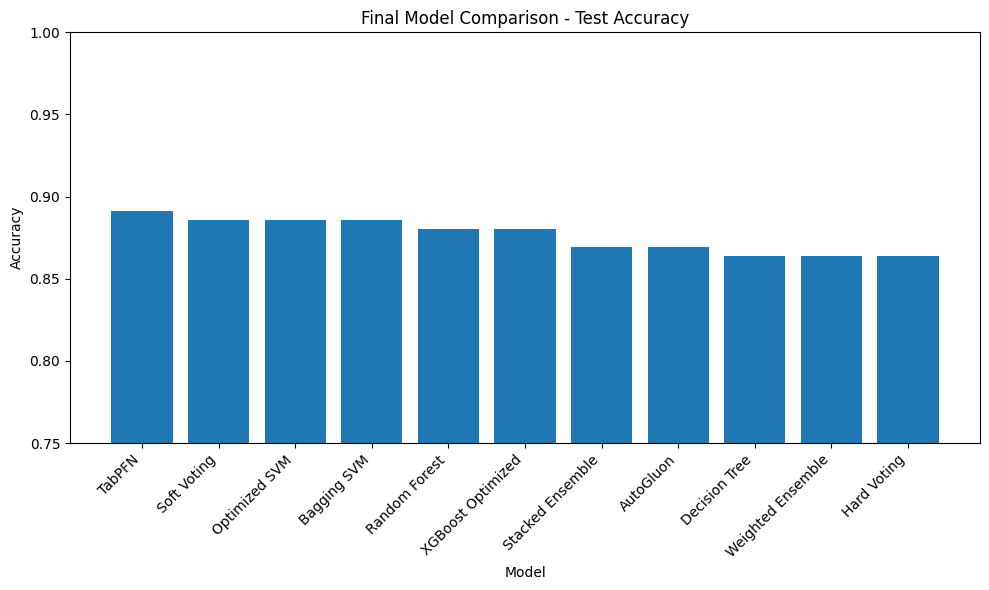

In [43]:
# Final model comparison

results = []

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, decision_tree_model.predict(X_test)),
    "ROC AUC": roc_auc_score(y_test, decision_tree_model.predict_proba(X_test)[:, 1])
})

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, random_forest_model.predict(X_test)),
    "ROC AUC": roc_auc_score(y_test, random_forest_model.predict_proba(X_test)[:, 1])
})

results.append({
    "Model": "XGBoost Optimized",
    "Accuracy": xgb_accuracy,
    "ROC AUC": xgb_auc
})

results.append({
    "Model": "Stacked Ensemble",
    "Accuracy": stack_accuracy,
    "ROC AUC": stack_auc
})

results.append({
    "Model": "Weighted Ensemble",
    "Accuracy": weighted_accuracy,
    "ROC AUC": weighted_auc
})

results.append({
    "Model": "Hard Voting",
    "Accuracy": hard_accuracy,
    "ROC AUC": np.nan
})

results.append({
    "Model": "Soft Voting",
    "Accuracy": soft_accuracy,
    "ROC AUC": soft_auc
})

results.append({
    "Model": "Optimized SVM",
    "Accuracy": svm_accuracy,
    "ROC AUC": svm_auc
})

results.append({
    "Model": "Bagging SVM",
    "Accuracy": bagging_accuracy,
    "ROC AUC": bagging_auc
})

try:
    results.append({
        "Model": "AutoGluon",
        "Accuracy": autogluon_accuracy,
        "ROC AUC": autogluon_auc
    })
except:
    pass

try:
    results.append({
        "Model": "TabPFN",
        "Accuracy": tabpfn_accuracy,
        "ROC AUC": tabpfn_auc
    })
except:
    pass

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df)

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Final Model Comparison - Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.75, 1.0)
plt.tight_layout()
plt.show()


The final model comparison shows that TabPFN achieved the highest test accuracy (0.8913), making it the best-performing model by accuracy on this dataset. Soft Voting, Optimized SVM, and Bagging SVM followed closely with accuracies of 0.8859, showing that ensemble and tuned kernel-based methods also performed very well. In terms of ROC AUC, Random Forest had the highest score (0.9423), slightly above XGBoost and TabPFN, meaning it separated heart disease and non-heart disease cases very strongly. Overall, the results suggest that TabPFN gave the best classification accuracy, while Random Forest provided the strongest probability-based discrimination.